In [ ]:
!pip -q install transformers datasets accelerate evaluate scikit-learn

import os, re, csv
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/Advanced Machine Learning/train NLP.csv"
TEST_PATH  = "/content/drive/MyDrive/Advanced Machine Learning/test NLP.csv"
OUTPUT_DIR = "/content/nlp_project_output"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())


Train shape: (7614, 1)
Test shape: (3264, 1)

Train columns: ['train']
Test columns: ['test']


In [ ]:
def normalize(s):
    return str(s).strip().lower()

def best_text_col(df):
    # prefer common names
    preferred = ["text","essay","content","response","sentence","review","train"]
    cols = df.columns.tolist()
    low = {normalize(c): c for c in cols}
    for p in preferred:
        if p in low:
            return low[p]


    best = None
    best_len = -1
    for c in cols:
        if pd.api.types.is_numeric_dtype(df[c]):
            continue
        sample = df[c].dropna().astype(str).head(200)
        if len(sample) == 0:
            continue
        avg_len = sample.str.len().mean()
        if avg_len > best_len:
            best_len = avg_len
            best = c
    return best

def best_label_col(df):

    preferred = ["label","target","class","y","category","subject","teacher","score"]
    cols = df.columns.tolist()
    low = {normalize(c): c for c in cols}
    for p in preferred:
        if p in low:
            return low[p]


    best = None
    best_uniques = 10**9
    for c in cols:
        if c is None:
            continue
        if pd.api.types.is_numeric_dtype(df[c]) or df[c].dtype == object:
            nunq = df[c].nunique(dropna=True)
            # labels usually have not-too-many classes
            if 2 <= nunq <= 200 and nunq < best_uniques:
                best_uniques = nunq
                best = c
    return best

def best_id_col(df):
    preferred = ["id","index"]
    cols = df.columns.tolist()
    low = {normalize(c): c for c in cols}
    for p in preferred:
        if p in low:
            return low[p]
    return None

text_col = best_text_col(train_df)
label_col = best_label_col(train_df)
test_id_col = best_id_col(test_df)

# If test has no id, create one
if test_id_col is None:
    test_df = test_df.reset_index().rename(columns={"index": "id"})
    test_id_col = "id"

print("\n✅ Auto-selected columns:")
print("text_col:", text_col)
print("label_col:", label_col)
print("test_id_col:", test_id_col)

# If it STILL couldn't find a label, it will NOT crash — it will show you what to set
if label_col is None:
    print("\n⚠️ I couldn't safely detect your label column.")
    print("Here are your train columns again:")
    print(train_df.columns.tolist())
    print("\n👉 FIX: set label_col manually like this (then re-run this cell):")
    print('label_col = "PUT_YOUR_LABEL_COLUMN_NAME_HERE"')



✅ Auto-selected columns:
text_col: train
label_col: train
test_id_col: id


In [ ]:
def clean_text(s):
    if pd.isna(s):
        return ""
    s = str(s)
    s = re.sub(r"\s+", " ", s).strip()
    return s



# Re-define helper functions for column detection (originally in iKn5zoCV_0Ck)
def normalize(s):
    return str(s).strip().lower()

def best_text_col(df):
    preferred = ["text","essay","content","response","sentence","review","train"]
    cols = df.columns.tolist()
    low = {normalize(c): c for c in cols}
    for p in preferred:
        if p in low:
            return low[p]
    best = None
    best_len = -1
    for c in cols:
        if pd.api.types.is_numeric_dtype(df[c]):
            continue
        sample = df[c].dropna().astype(str).head(200)
        if len(sample) == 0:
            continue
        avg_len = sample.str.len().mean()
        if avg_len > best_len:
            best_len = avg_len
            best = c
    return best

def best_label_col(df):
    preferred = ["label","target","class","y","category","subject","teacher","score"]
    cols = df.columns.tolist()
    low = {normalize(c): c for c in cols}
    for p in preferred:
        if p in low:
            return low[p]
    best = None
    best_uniques = 10**9
    for c in cols:
        if c is None:
            continue
        if pd.api.types.is_numeric_dtype(df[c]) or df[c].dtype == object:
            nunq = df[c].nunique(dropna=True)
            if 2 <= nunq <= 200 and nunq < best_uniques:
                best_uniques = nunq
                best = c
    return best

def best_id_col(df):
    preferred = ["id","index"]
    cols = df.columns.tolist()
    low = {normalize(c): c for c in cols}
    for p in preferred:
        if p in low:
            return low[p]
    return None

# Manual parsing for non-standard CSV format
try:
    # Read header for train_df (skip first line, read second as header)
    with open(TRAIN_PATH, 'r') as f:
        f.readline() # Skip the first line ('train' or similar placeholder)
        train_header_line = f.readline().strip()
        train_column_names = train_header_line.split(',') # FIX: Split by comma

    # Read header for test_df (skip first line, read second as header)
    with open(TEST_PATH, 'r') as f:
        f.readline() # Skip the first line ('test' or similar placeholder)
        test_header_line = f.readline().strip()
        test_column_names = test_header_line.split(',') # FIX: Split by comma

    # Load dataframes, skipping the first two rows and assigning manual headers
    train_df = pd.read_csv(TRAIN_PATH, skiprows=2, header=None, names=train_column_names, sep=',', engine='python') # FIX: Use comma separator
    test_df  = pd.read_csv(TEST_PATH, skiprows=2, header=None, names=test_column_names, sep=',', engine='python') # FIX: Use comma separator
    print("✅ Dataframes reloaded with manual header parsing and comma separator.")
except Exception as e:
    print(f"Error with manual header parsing and comma separator: {e}. Trying default comma separator as fallback.")
    # Fallback to default read_csv if manual parsing fails. This might lead to previous errors.
    train_df = pd.read_csv(TRAIN_PATH)
    test_df  = pd.read_csv(TEST_PATH)

# Re-evaluate text_col, label_col, test_id_col after reloading dataframes
text_col = best_text_col(train_df)
label_col = best_label_col(train_df)
test_id_col = best_id_col(test_df)

# If test has no id, create one (replicating logic from iKn5zoCV_0Ck)
if test_id_col is None:
    test_df = test_df.reset_index().rename(columns={"index": "id"})
    test_id_col = "id"

print("\n✅ Auto-selected columns (after reload):")
print("text_col:", text_col)
print("label_col:", label_col)
print("test_id_col:", test_id_col)

# If it STILL couldn't find a label, raise a clear error (replicating logic from iKn5zoCV_0Ck)
if label_col is None:
    print("\n⚠️ I couldn't safely detect your label column after reloading.")
    print("Here are your train columns again:")
    print(train_df.columns.tolist())
    print("\n👉 FIX: set label_col manually like this (then re-run this cell):")
    print('label_col = "PUT_YOUR_LABEL_COLUMN_NAME_HERE"')
    raise ValueError("STOP: label_col not detected after attempting reload and re-detection.")




if text_col is None:
    raise ValueError("No text column could be detected. Your CSV might be empty or formatted strangely.")

train_df[text_col] = train_df[text_col].apply(clean_text)
test_df[text_col]  = test_df[text_col].apply(clean_text)

# If label_col is missing, stop HERE with instructions (this check is now partly redundant but harmless)
if label_col is None:
    raise ValueError("STOP: label_col not detected. In Cell 3, set label_col manually to your label column name.")

# Convert label to int if possible, otherwise factorize
if not pd.api.types.is_integer_dtype(train_df[label_col]):
    # factorize string labels into integers
    train_df[label_col], label_mapping = pd.factorize(train_df[label_col])
    print("\nLabel mapping (original -> int):")
    print(dict(enumerate(label_mapping)))
else:
    label_mapping = None

# HF datasets
hf_train = Dataset.from_pandas(
    train_df[[text_col, label_col]].rename(columns={text_col: "text", label_col: "label"})
)
hf_test = Dataset.from_pandas(
    test_df[[test_id_col, text_col]].rename(columns={test_id_col: "id", text_col: "text"})
)

splits = hf_train.train_test_split(test_size=0.15, seed=42)
train_ds, val_ds = splits["train"], splits["test"]

print("\nTrain/Val sizes:", len(train_ds), len(val_ds))


✅ Dataframes reloaded with manual header parsing and comma separator.

✅ Auto-selected columns (after reload):
text_col: text
label_col: target
test_id_col: id

Train/Val sizes: 6471 1142


In [ ]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True)

train_tok = train_ds.map(tokenize, batched=True)
val_tok   = val_ds.map(tokenize, batched=True)
test_tok  = hf_test.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/6471 [00:00<?, ? examples/s]

Map:   0%|          | 0/1142 [00:00<?, ? examples/s]

Map:   0%|          | 0/3263 [00:00<?, ? examples/s]

In [ ]:
set_seed(42)

num_labels = int(pd.Series(train_df[label_col]).nunique())
print("num_labels:", num_labels)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# SPEED BOOST: freeze base model
for p in model.base_model.parameters():
    p.requires_grad = False

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch", # FIX: Changed from evaluation_strategy to eval_strategy
    save_strategy="no",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("GPU available?", torch.cuda.is_available())

num_labels: 2


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-482614929.py:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


GPU available? False


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.582900,0.578669,0.741681


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Eval: {'eval_loss': 0.5786688327789307, 'eval_accuracy': 0.7416812609457093, 'eval_runtime': 106.2388, 'eval_samples_per_second': 10.749, 'eval_steps_per_second': 0.678, 'epoch': 1.0}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Confusion Matrix:
 [[609  44]
 [251 238]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.93      0.81       653
           1       0.84      0.49      0.62       489

    accuracy                           0.74      1142
   macro avg       0.78      0.71      0.71      1142
weighted avg       0.77      0.74      0.72      1142



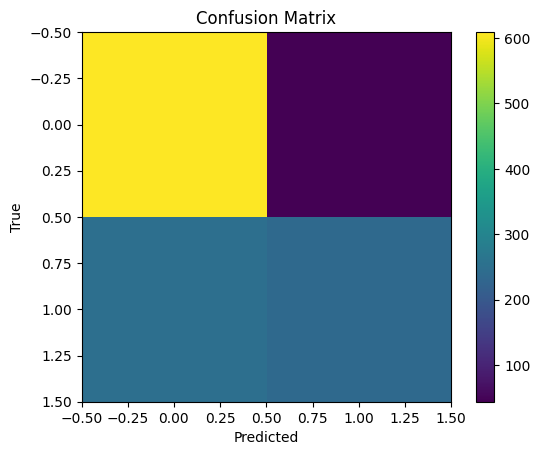

In [ ]:
trainer.train()
eval_out = trainer.evaluate()
print("Eval:", eval_out)

val_logits = trainer.predict(val_tok).predictions
val_preds = np.argmax(val_logits, axis=1)
val_labels = np.array(val_tok["label"])

cm = confusion_matrix(val_labels, val_preds)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(val_labels, val_preds))

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


In [ ]:
print("Predicting test...")

test_logits = trainer.predict(test_tok).predictions
test_preds = np.argmax(test_logits, axis=1)

os.makedirs(OUTPUT_DIR, exist_ok=True)
out_path = os.path.join(OUTPUT_DIR, "predict_results.csv")

with open(out_path, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["id", "target"])
    for i, pred in enumerate(test_preds):
        w.writerow([hf_test[i]["id"], int(pred)])

print("✅ Saved:", out_path)
pd.read_csv(out_path).head()


Predicting test...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


✅ Saved: /content/nlp_project_output/predict_results.csv


,id,target
0,0,0
1,2,0
2,3,0
3,9,1
4,11,1


In [ ]:
from google.colab import files
files.download("/content/nlp_project_output/predict_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>